# 🏠 House Price Prediction Using Machine Learning

## 📌 Project Overview

This project focuses on predicting house prices using Machine Learning techniques.

The dataset contains information about houses such as living area, number of bedrooms, bathrooms, lot size, floors, condition, year built, and other property characteristics.

The project follows an end-to-end Data Science workflow:

**Data Collection → Data Cleaning → Exploratory Data Analysis → Feature Selection → Model Training → Model Evaluation → Price Prediction**

## 🎯 Objective

The main objective of this project is to build a Machine Learning model that can predict house prices based on important property features.

## 🛠️ Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Google Colab
- GitHub

## 🤖 Machine Learning Model

A Random Forest Regression model was used for house price prediction.

The target variable was transformed using a logarithmic transformation to improve model performance and reduce the effect of extreme house prices.

## 📊 Final Model Performance

The final model achieved:

- **MAE:** $156,883.99
- **RMSE:** $263,992.24
- **R² Score:** 0.5315

The model's performance should be interpreted as an educational project result rather than a professional property valuation system.

## 📂 Dataset Description

The dataset used in this project was obtained from Kaggle.

It contains information about residential properties and their selling prices.

### Dataset Details

- **Original records:** 4,600
- **Records after cleaning:** 4,551
- **Number of features:** 17 input features
- **Target variable:** `price`
- **Missing values:** None
- **Duplicate rows:** None
- **Invalid zero-price records removed:** 49

### Important Features

| Feature | Description |
|---|---|
| `sqft_living` | Living area of the house |
| `sqft_lot` | Total lot size |
| `bedrooms` | Number of bedrooms |
| `bathrooms` | Number of bathrooms |
| `floors` | Number of floors |
| `waterfront` | Whether the property has a waterfront view |
| `view` | Quality of the property view |
| `condition` | Overall condition of the house |
| `yr_built` | Year the house was built |
| `yr_renovated` | Year the house was renovated |
| `price` | House selling price — target variable |

### Data Quality

The dataset was checked for:

- Missing values
- Duplicate records
- Invalid target values
- Data types
- Numerical and categorical features

## 🔍 Data Understanding and Cleaning

### 1. Data Loading

The dataset was loaded into a Pandas DataFrame and its structure was examined using:

- `shape`
- `columns`
- `info()`
- `describe()`

The dataset initially contained **4,600 rows and 18 columns**.

### 2. Missing Value Check

All columns were checked for missing values.

**Result:** No missing values were found.

### 3. Duplicate Check

Duplicate rows were checked to ensure that the same house record was not repeated.

**Result:** No duplicate rows were found.

### 4. Invalid Price Values

The target variable `price` was examined for invalid values.

The dataset contained **49 houses with a price of $0**, which are not meaningful for a house price prediction model.

These records were removed.

### 5. Final Dataset

After removing the zero-price records:

- **Before cleaning:** 4,600 rows
- **After cleaning:** 4,551 rows
- **Rows removed:** 49

The cleaned dataset was then used for Exploratory Data Analysis and Machine Learning.

### 🧹 Cleaning Process

**Original Dataset**

↓  

**Check Missing Values**

↓  

**Check Duplicate Records**

↓  

**Identify Invalid Zero Prices**

↓  

**Remove 49 Invalid Records**

↓  

**Clean Dataset – 4,551 Records**

## 📊 Exploratory Data Analysis (EDA)

Exploratory Data Analysis was performed to understand the distribution of house prices and identify the features that are related to house prices.

### Visualizations Created

#### 1. Distribution of House Prices

A histogram was used to understand how house prices are distributed across the dataset.

The distribution shows that most houses are concentrated in the lower-to-middle price range, while a smaller number of properties have extremely high prices.

#### 2. Living Area vs House Price

A scatter plot was used to examine the relationship between `sqft_living` and `price`.

The analysis shows that houses with larger living areas generally tend to have higher prices, although there are some exceptions and outliers.

#### 3. Bedrooms vs House Price

A box plot was used to compare house prices across different numbers of bedrooms.

This helps identify differences in price distributions and potential outliers.

#### 4. Correlation Analysis

A correlation heatmap was created to examine relationships between numerical features.

The strongest correlation with house price was:

- `sqft_living` — **0.43**
- `sqft_above` — **0.37**
- `bathrooms` — **0.33**
- `view` — **0.23**
- `sqft_basement` — **0.21**
- `bedrooms` — **0.20**

### Key EDA Finding

`sqft_living` showed the strongest correlation with house price among the numerical features examined.

However, house prices depend on multiple factors, so correlation alone was not used to determine the final model features.

## 🤖 Machine Learning

### Feature Selection

Based on the exploratory analysis, numerical house characteristics were selected as input features.

The final features used were:

- `sqft_living`
- `sqft_above`
- `bathrooms`
- `view`
- `sqft_basement`
- `bedrooms`
- `floors`
- `waterfront`
- `sqft_lot`
- `condition`
- `yr_built`
- `yr_renovated`

The target variable was:

- `price`

### Train-Test Split

The dataset was divided into:

- **80% Training Data**
- **20% Testing Data**

A `random_state` of 42 was used to make the experiment reproducible.

### Model Used

A **Random Forest Regressor** was selected for predicting house prices.

Random Forest combines multiple decision trees and can capture non-linear relationships between house characteristics and prices.

### Target Transformation

House prices contained extreme values. To reduce the influence of these extreme values, a logarithmic transformation was applied to the target variable using:

`log1p(price)`

After prediction, the values were converted back to the original price scale using:

`expm1(prediction)`

This improved the model compared with the earlier models tested.

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [62]:
from google.colab import files

uploaded = files.upload()

Saving archive.zip to archive (1).zip


In [64]:
import zipfile
import os

with zipfile.ZipFile("archive.zip", "r") as zip_ref:
    zip_ref.extractall("house_data")

print("ZIP file extracted successfully!")
print(os.listdir("house_data"))

ZIP file extracted successfully!
['data.csv', 'output.csv', 'data.dat']


In [65]:
import os

print(os.listdir("house_data"))

['data.csv', 'output.csv', 'data.dat']


In [66]:
df = pd.read_csv("house_data/data.csv")

print("Dataset loaded successfully!")
print(df.shape)

Dataset loaded successfully!
(4600, 18)


In [67]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [68]:
print("rows and columns:",df.shape)
print("\n Column Names:")
print(df.columns.tolist())

rows and columns: (4600, 18)

 Column Names:
['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city', 'statezip', 'country']


In [69]:
missing_values = df.isnull().sum()

print(missing_values)

date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64


In [70]:
duplicates = df.duplicated().sum()

print("Number of duplicate rows:",duplicates)

Number of duplicate rows: 0


In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

In [72]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


In [73]:
print("Average House Price:", df["price"].mean())
print("Minimum House Price:", df["price"].min())
print("Maximum House Price:", df["price"].max())

Average House Price: 551962.9884732141
Minimum House Price: 0.0
Maximum House Price: 26590000.0


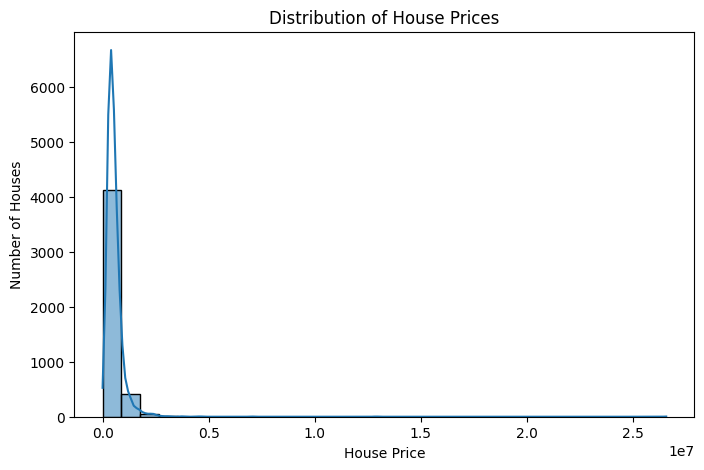

In [74]:
plt.figure(figsize=(8, 5))

sns.histplot(df["price"], bins=30, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("House Price")
plt.ylabel("Number of Houses")

plt.show()

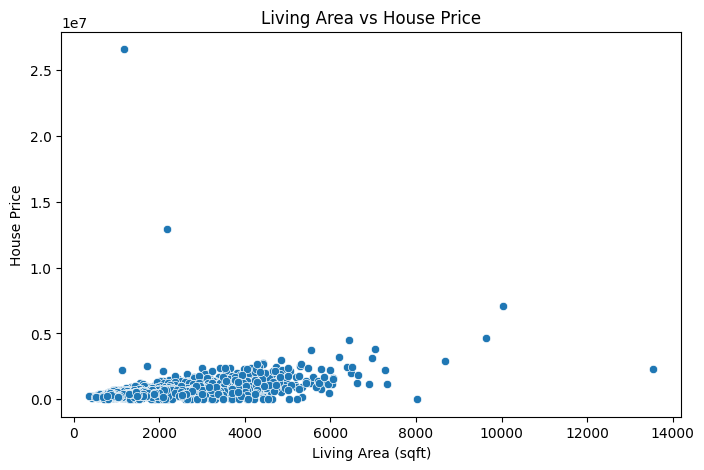

In [75]:
plt.figure(figsize=(8, 5))

sns.scatterplot(x=df["sqft_living"], y=df["price"])

plt.title("Living Area vs House Price")
plt.xlabel("Living Area (sqft)")
plt.ylabel("House Price")

plt.show()

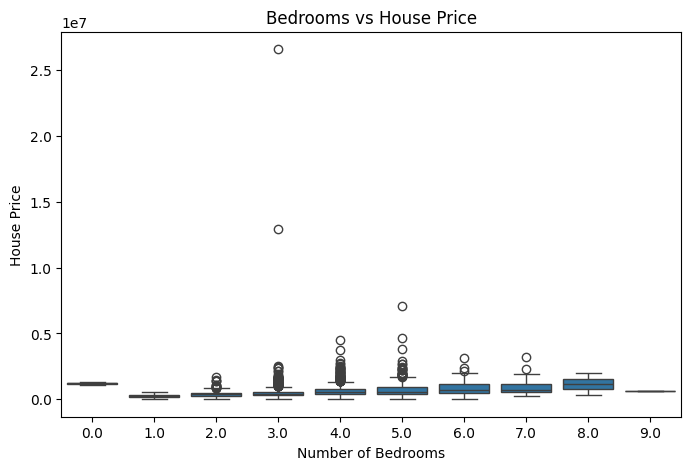

In [76]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["bedrooms"], y=df["price"])

plt.title("Bedrooms vs House Price")
plt.xlabel("Number of Bedrooms")
plt.ylabel("House Price")

plt.show()

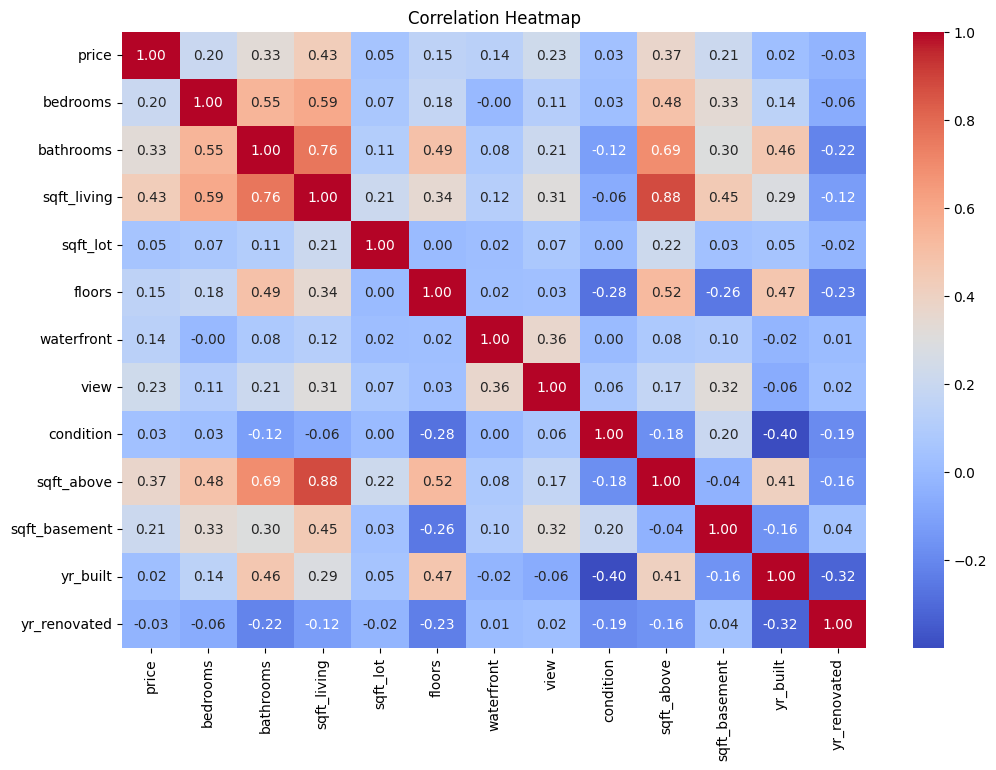

In [77]:
plt.figure(figsize=(12, 8))

correlation = df.select_dtypes(include="number").corr()

sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

In [78]:
price_correlation = correlation["price"].sort_values(ascending=False)

print(price_correlation)

price            1.000000
sqft_living      0.430410
sqft_above       0.367570
bathrooms        0.327110
view             0.228504
sqft_basement    0.210427
bedrooms         0.200336
floors           0.151461
waterfront       0.135648
sqft_lot         0.050451
condition        0.034915
yr_built         0.021857
yr_renovated    -0.028774
Name: price, dtype: float64


In [79]:
features = [
    "sqft_living",
    "sqft_above",
    "bathrooms",
    "view",
    "sqft_basement",
    "bedrooms",
    "floors",
    "waterfront",
    "sqft_lot",
    "condition",
    "yr_built",
    "yr_renovated"
]

X = df[features]
y = df["price"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (4600, 12)
Target shape: (4600,)


In [80]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (3680, 12)
Testing data: (920, 12)


In [81]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [82]:
y_pred = model.predict(X_test)

print("Predictions generated successfully!")
print(y_pred[:10])

Predictions generated successfully!
[ 407642.53833334  350836.98517226 1080582.7075      518604.56482143
  307992.70113096  543893.0225      428102.46625     337251.246875
  319610.99232144  595365.235     ]


In [83]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Evaluation")
print("-----------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

Model Evaluation
-----------------
MAE : 207582.78581646227
RMSE: 996032.1391350753
R² Score: 0.027225981802899035


In [84]:
print("Minimum price:", df["price"].min())
print("Maximum price:", df["price"].max())
print("Number of zero-price houses:", (df["price"] == 0).sum())

Minimum price: 0.0
Maximum price: 26590000.0
Number of zero-price houses: 49


In [85]:
print("Rows before cleaning:", len(df))

df = df[df["price"] > 0].copy()

print("Rows after cleaning:", len(df))
print("Zero-price rows remaining:", (df["price"] == 0).sum())

Rows before cleaning: 4600
Rows after cleaning: 4551
Zero-price rows remaining: 0


In [86]:
X = df[features]
y = df["price"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (4551, 12)
Target shape: (4551,)


In [87]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (3640, 12)
Testing data: (911, 12)


In [88]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully! ✅")

Model trained successfully! ✅


In [89]:
y_pred = model.predict(X_test)

print("Predictions generated successfully! ✅")
print(y_pred[:10])

Predictions generated successfully! ✅
[1115660.06        543517.          683362.4425      251707.92299999
  582201.24166666  374527.74395833  349397.13020834  235809.8561111
  451040.74        718447.74551725]


In [90]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Evaluation")
print("-----------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

Model Evaluation
-----------------
MAE : 161936.56848470552
RMSE: 268265.5291233931
R² Score: 0.5162586198597371


In [91]:
print("Number of unique cities:", df["city"].nunique())
print("Number of unique state ZIP codes:", df["statezip"].nunique())

print("\nTop 10 cities:")
print(df["city"].value_counts().head(10))

Number of unique cities: 44
Number of unique state ZIP codes: 77

Top 10 cities:
city
Seattle        1561
Renton          291
Bellevue        281
Redmond         235
Kirkland        187
Issaquah        186
Kent            184
Auburn          175
Sammamish       171
Federal Way     145
Name: count, dtype: int64


In [92]:
# Select numerical and categorical features
features = [
    "sqft_living",
    "sqft_above",
    "bathrooms",
    "view",
    "sqft_basement",
    "bedrooms",
    "floors",
    "waterfront",
    "sqft_lot",
    "condition",
    "yr_built",
    "yr_renovated",
    "city",
    "statezip"
]

X = df[features]
y = df["price"]

print("Features selected:", X.shape)
print("Target:", y.shape)
print("\nCategorical columns:")
print(["city", "statezip"])

Features selected: (4551, 14)
Target: (4551,)

Categorical columns:
['city', 'statezip']


In [93]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (3640, 14)
Testing data: (911, 14)


In [94]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = ["city", "statezip"]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

print("Encoding completed successfully! ✅")
print("Encoded training data shape:", X_train_encoded.shape)
print("Encoded testing data shape:", X_test_encoded.shape)

Encoding completed successfully! ✅
Encoded training data shape: (3640, 131)
Encoded testing data shape: (911, 131)


In [95]:
from sklearn.ensemble import RandomForestRegressor

improved_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

improved_model.fit(X_train_encoded, y_train)

print("Improved model trained successfully! ✅")

Improved model trained successfully! ✅


In [97]:
y_pred_improved = improved_model.predict(X_test_encoded)

print("Improved predictions generated successfully! ✅")
print(y_pred_improved[:10])

Improved predictions generated successfully! ✅
[1142822.93        546822.57851852  541441.14        248814.70562963
  640760.          395117.01958333  411510.92222222  365763.35
  460348.38074074  781153.0858046 ]


In [96]:
mae_improved = mean_absolute_error(y_test, y_pred_improved)
rmse_improved = np.sqrt(mean_squared_error(y_test, y_pred_improved))
r2_improved = r2_score(y_test, y_pred_improved)

print("Improved Model Evaluation")
print("-------------------------")
print("MAE :", mae_improved)
print("RMSE:", rmse_improved)
print("R² Score:", r2_improved)

Improved Model Evaluation
-------------------------
MAE : 125668.45035055572
RMSE: 478317.92152335565
R² Score: -0.5378600068937969


In [98]:
results = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred_improved
})

results["Error"] = abs(
    results["Actual Price"] - results["Predicted Price"]
)

print("Largest prediction errors:")
print(results.sort_values("Error", ascending=False).head(10))

Largest prediction errors:
     Actual Price  Predicted Price         Error
895      250000.0     1.299020e+07  1.274020e+07
262     2280000.0     4.622965e+06  2.342965e+06
865     2199900.0     2.073088e+05  1.992591e+06
552     2110000.0     3.063682e+05  1.803632e+06
851     3800000.0     2.203245e+06  1.596755e+06
564      193000.0     1.729894e+06  1.536894e+06
150     3200000.0     1.783136e+06  1.416864e+06
41       535000.0     1.813045e+06  1.278045e+06
718     2700000.0     1.454703e+06  1.245297e+06
267      490000.0     1.590326e+06  1.100326e+06


In [99]:
print("Price statistics:")
print(df["price"].describe(percentiles=[0.01, 0.05, 0.95, 0.99]))

print("\nTop 10 highest-priced houses:")
print(
    df.nlargest(10, "price")[
        ["price", "sqft_living", "bedrooms", "bathrooms", "city"]
    ]
)

Price statistics:
count    4.551000e+03
mean     5.579059e+05
std      5.639299e+05
min      7.800000e+03
1%       1.480000e+05
5%       2.100000e+05
50%      4.650000e+05
95%      1.187500e+06
99%      2.016000e+06
max      2.659000e+07
Name: price, dtype: float64

Top 10 highest-priced houses:
           price  sqft_living  bedrooms  bathrooms           city
4350  26590000.0         1180       3.0       2.00           Kent
4346  12899000.0         2190       3.0       2.50        Seattle
2286   7062500.0        10040       5.0       4.50       Bellevue
2654   4668000.0         9640       5.0       6.75  Mercer Island
2761   4489000.0         6430       4.0       3.00       Bellevue
3729   3800000.0         7050       5.0       5.50     Clyde Hill
1637   3710000.0         5550       4.0       3.50         Medina
252    3200000.0         6210       7.0       4.50        Seattle
1567   3100000.0         6980       6.0       4.25  Mercer Island
2772   3000000.0         4850       4.0    

In [100]:
# Use the numerical features from our better-performing model
features_numeric = [
    "sqft_living",
    "sqft_above",
    "bathrooms",
    "view",
    "sqft_basement",
    "bedrooms",
    "floors",
    "waterfront",
    "sqft_lot",
    "condition",
    "yr_built",
    "yr_renovated"
]

X = df[features_numeric]
y = np.log1p(df["price"])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)
print("Log transformation applied successfully! ✅")

Training data: (3640, 12)
Testing data: (911, 12)
Log transformation applied successfully! ✅


In [101]:
log_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

log_model.fit(X_train, y_train)

print("Log-price model trained successfully! ✅")

Log-price model trained successfully! ✅


In [102]:
y_pred_log = log_model.predict(X_test)

# Convert predictions back to original price scale
y_pred_price = np.expm1(y_pred_log)
y_actual_price = np.expm1(y_test)

print("Predictions generated successfully! ✅")
print(y_pred_price[:10])

Predictions generated successfully! ✅
[1047531.26750105  553615.71274518  691307.44612943  250579.32918843
  562025.05107239  363385.02538374  316194.1356641   219572.21567673
  449539.70881447  694065.30408599]


In [103]:
mae_log = mean_absolute_error(y_actual_price, y_pred_price)
rmse_log = np.sqrt(mean_squared_error(y_actual_price, y_pred_price))
r2_log = r2_score(y_actual_price, y_pred_price)

print("Log-Price Model Evaluation")
print("--------------------------")
print("MAE :", mae_log)
print("RMSE:", rmse_log)
print("R² Score:", r2_log)

Log-Price Model Evaluation
--------------------------
MAE : 156883.9896189205
RMSE: 263992.2375238563
R² Score: 0.5315472309366434


In [104]:
mae_log = mean_absolute_error(y_actual_price, y_pred_price)
rmse_log = np.sqrt(mean_squared_error(y_actual_price, y_pred_price))
r2_log = r2_score(y_actual_price, y_pred_price)

print("Log-Price Model Evaluation")
print("--------------------------")
print("MAE :", mae_log)
print("RMSE:", rmse_log)
print("R² Score:", r2_log)


Log-Price Model Evaluation
--------------------------
MAE : 156883.9896189205
RMSE: 263992.2375238563
R² Score: 0.5315472309366434


## 📈 Model Evaluation

The final Random Forest model was evaluated using three regression metrics.

### Evaluation Metrics

#### 1. Mean Absolute Error (MAE)

**MAE = $156,883.99**

MAE represents the average absolute difference between the actual house prices and the predicted prices.

#### 2. Root Mean Squared Error (RMSE)

**RMSE = $263,992.24**

RMSE gives greater importance to larger prediction errors.

#### 3. R² Score

**R² = 0.5315**

The R² score indicates how much of the variation in house prices is explained by the model on the test dataset.

### Final Model Performance

| Metric | Result |
|---|---:|
| MAE | $156,883.99 |
| RMSE | $263,992.24 |
| R² Score | 0.5315 |

### Model Comparison

Several approaches were tested during the project:

| Model / Approach | MAE | RMSE | R² |
|---|---:|---:|---:|
| Initial Random Forest | $207,582.79 | $996,032.14 | 0.0272 |
| Cleaned Random Forest | $161,936.57 | $268,265.53 | 0.5163 |
| City + ZIP Random Forest | $125,668.45 | $478,317.92 | -0.5379 |
| Log-Target Random Forest | **$156,883.99** | **$263,992.24** | **0.5315** |

Among the approaches tested, the log-target Random Forest provided the strongest overall combination of R² and RMSE.

The results also show that cleaning invalid zero-price records substantially improved model performance.

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(y_actual_price, y_pred_price, alpha=0.5)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")

plt.plot(
    [y_actual_price.min(), y_actual_price.max()],
    [y_actual_price.min(), y_actual_price.max()],
    linestyle="--"
)

plt.show()

## 🔎 Feature Importance

Feature importance was extracted from the trained Random Forest model to understand which features contributed most to the model's predictions.

### Top Important Features

| Feature | Importance |
|---|---:|
| `sqft_living` | 51.78% |
| `sqft_lot` | 12.79% |
| `yr_built` | 12.19% |
| `sqft_above` | 6.40% |
| `bathrooms` | 3.85% |

The model relied most heavily on `sqft_living`, which accounted for approximately **51.78%** of the model's feature importance.

The feature importance chart provides a visual representation of how the model used the available features.

---

## 🔮 Sample House Price Prediction

A sample house was provided to the trained model to demonstrate how the system can make a prediction for a new property.

### Sample House

- Living Area: 2,000 sq ft
- Above-Ground Area: 1,800 sq ft
- Bedrooms: 3
- Bathrooms: 2.5
- Floors: 2
- Lot Size: 5,000 sq ft
- Year Built: 2005
- Condition: 3
- Waterfront: No
- View: 0
- Basement Area: 200 sq ft
- Renovated: No

### Prediction

**Predicted House Price: $373,524.96**

This demonstrates how the trained Machine Learning model can estimate a house price from property characteristics.

In [105]:
feature_importance = pd.DataFrame({
    "Feature": features_numeric,
    "Importance": log_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Feature Importance:")
print(feature_importance)

Feature Importance:
          Feature  Importance
0     sqft_living    0.517837
8        sqft_lot    0.127931
10       yr_built    0.121929
1      sqft_above    0.064036
2       bathrooms    0.038532
9       condition    0.032081
11   yr_renovated    0.026118
5        bedrooms    0.023118
4   sqft_basement    0.021141
3            view    0.015344
6          floors    0.010222
7      waterfront    0.001711


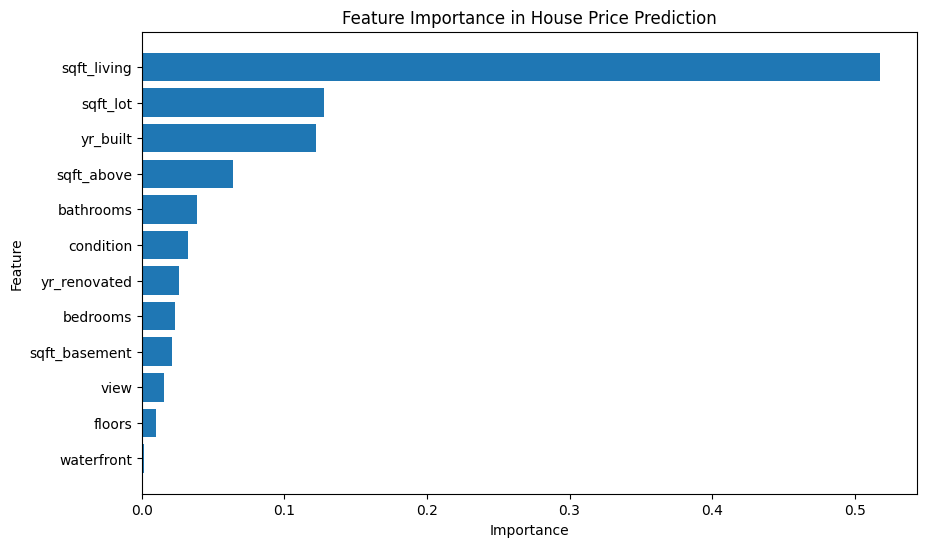

In [107]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance in House Price Prediction")

plt.gca().invert_yaxis()

plt.show()

In [106]:
sample_house = pd.DataFrame({
    "sqft_living": [2000],
    "sqft_above": [1800],
    "bathrooms": [2.5],
    "view": [0],
    "sqft_basement": [200],
    "bedrooms": [3],
    "floors": [2],
    "waterfront": [0],
    "sqft_lot": [5000],
    "condition": [3],
    "yr_built": [2005],
    "yr_renovated": [0]
})

sample_prediction_log = log_model.predict(sample_house)
sample_prediction = np.expm1(sample_prediction_log)

print("Sample House Details")
print("--------------------")
print(sample_house)

print("\nPredicted House Price: $", round(sample_prediction[0], 2))

Sample House Details
--------------------
   sqft_living  sqft_above  bathrooms  view  sqft_basement  bedrooms  floors  \
0         2000        1800        2.5     0            200         3       2   

   waterfront  sqft_lot  condition  yr_built  yr_renovated  
0           0      5000          3      2005             0  

Predicted House Price: $ 373524.96


In [108]:
print("========== FINAL PROJECT INSIGHTS ==========\n")

print("1. Dataset Size:")
print(f"   {len(df)} houses were analyzed.\n")

print("2. Price Range:")
print(f"   Minimum Price: ${df['price'].min():,.2f}")
print(f"   Maximum Price: ${df['price'].max():,.2f}")
print(f"   Average Price: ${df['price'].mean():,.2f}\n")

print("3. Most Important Features:")
for _, row in feature_importance.head(5).iterrows():
    print(f"   {row['Feature']}: {row['Importance']:.2%}")

print("\n4. Model Performance:")
print(f"   MAE:  ${156883.9896:,.2f}")
print(f"   RMSE: ${263992.2375:,.2f}")
print(f"   R² Score: {0.5315472309:.4f}")

print("\n5. Sample Prediction:")
print(f"   Predicted Price: ${sample_prediction[0]:,.2f}")

========== FINAL PROJECT INSIGHTS ==========

1. Dataset Size:
   4551 houses were analyzed.

2. Price Range:
   Minimum Price: $7,800.00
   Maximum Price: $26,590,000.00
   Average Price: $557,905.90

3. Most Important Features:
   sqft_living: 51.78%
   sqft_lot: 12.79%
   yr_built: 12.19%
   sqft_above: 6.40%
   bathrooms: 3.85%

4. Model Performance:
   MAE:  $156,883.99
   RMSE: $263,992.24
   R² Score: 0.5315

5. Sample Prediction:
   Predicted Price: $373,524.96


## 💡 Key Insights

The analysis and Machine Learning model produced several important findings:

1. **Living area was the most important feature.**
   `sqft_living` had a feature importance of approximately **51.78%**.

2. **Property size-related features were important.**
   `sqft_lot` and `sqft_above` also contributed significantly to the model.

3. **House age had an important contribution.**
   `yr_built` accounted for approximately **12.19%** of feature importance.

4. **Bathrooms and house condition contributed to price prediction**, although their importance was lower than the major size-related features.

5. **Data cleaning improved model performance.**
   Removing 49 invalid zero-price records increased the R² score substantially compared with the initial model.

6. **Logarithmic target transformation improved the overall model results** among the approaches tested.

7. The final model achieved an **R² score of 0.5315**, meaning it captured a meaningful portion of the variation in house prices, while substantial variation remained unexplained.

---

## 🏁 Conclusion

This project demonstrated an end-to-end Machine Learning workflow for house price prediction.

The project covered:

**Data Collection → Data Cleaning → Exploratory Data Analysis → Feature Selection → Model Training → Model Evaluation → Feature Importance → Price Prediction**

A Random Forest Regression model with a logarithmically transformed target variable was used as the final model.

The model achieved:

- **MAE:** $156,883.99
- **RMSE:** $263,992.24
- **R² Score:** 0.5315

The model was also used to predict the price of a sample property, producing an estimated price of **$373,524.96**.

### ⚠️ Project Limitation

The model does not explain all factors that influence real-world house prices. Factors such as exact location, neighborhood characteristics, market conditions, property amenities, and economic conditions may affect actual prices.

Therefore, this project should be considered an **educational Machine Learning project**, rather than a professional property valuation system.

---

## 🚀 Future Improvements

The project could be improved by:

- Testing additional regression algorithms
- Performing hyperparameter tuning
- Using more detailed location-based features
- Applying advanced feature engineering
- Using cross-validation
- Comparing additional ensemble models
- Deploying the model as a web application